# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

# Постановка задачи

Пострить модель, которая умеет **определять стоимость автомобиля по его технических характеристикам**, комплектации.

Критерии, которые важны заказчику:
- качество предсказания;
- время обучения модели;
- время предсказания модели.

Для оценки качества моделей требуется применить метрику RMSE. Значение метрики **RMSE должно быть меньше 2500**.

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

## Описание данных

Описание данных
Данные находятся в файле /datasets/autos.csv. Скачать датасет. 
Признаки:
- DateCrawled — дата скачивания анкеты из базы:
- VehicleType — тип автомобильного кузова:
- RegistrationYear — год регистрации автомобиля:
- Gearbox — тип коробки передач:
- Power — мощность (л. с.):
- Model — модель автомобиля:
- Kilometer — пробег (км):
- RegistrationMonth — месяц регистрации автомобиля:
- FuelType — тип топлива:
- Brand — марка автомобиля:
- Repaired — была машина в ремонте или нет:
- DateCreated — дата создания анкеты:
- NumberOfPictures — количество фотографий автомобиля:
- PostalCode — почтовый индекс владельца анкеты (пользователя):
- LastSeen — дата последней активности пользователя:
- **Целевой признак:**
    - Price — цена (евро)

# Инициализация

## Импорт библиотек

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   MinMaxScaler, StandardScaler)
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.svm import SVC 

from sklearn.model_selection import train_test_split, \
                                RandomizedSearchCV #, GridSearchCV
import numpy as np

from sklearn.pipeline import Pipeline

from sklearn.metrics import (root_mean_squared_error)

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report

import re

import time


In [2]:
!pip install phik -q
import phik

In [3]:
!pip install lightgbm -q
import lightgbm as lgb

In [4]:
!pip install category_encoders -q
from category_encoders import TargetEncoder

## Установка главных параметров

In [5]:
RANDOM_STATE = 42

# Вспомогательные функции

In [6]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

def def_load_csv(csv, print_info=True):
    df = pd.read_csv(correct_path(csv))
    if print_info:
        display(df.info())
        display(df.head())
    return df

def columns_to_snake_case (df):
    names = {}
    for c in df.columns:
        names [c] = re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower()
    df.rename(columns=names, inplace=True)
    return df

# визуализирует все категориальные фичи датафрейма в виде пирогов
# визуализирует все категориальные фичи датафрейма в виде ящиков с усами и гистограмм с распределением, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query(),
#   графики выводятся для каждого фильтра
#   чтобы вывести графики без фильтра нужно передать пустой запрос, или же не передавать фильтры вовсе


def keep_top_group_other (d, top_n = 10):
    vc = d.value_counts()
    l = len (vc)
    if l > top_n:
        t = vc[:top_n].index
        display(t)
        d = d.apply(lambda x: x if x in t else f'Other {l-top_n} categories')
    return d

def do_eda(df, filters=[]):
    bins=25
    n_filters = len(filters)
    PIE_WIDTH = 5

    # вывод графиков по категориальным фичам 
    for column in df:
        if df[column].dtype == 'O':
            title0 = f"столбец {column}, количество и доля значений"
            df_show = df[column]
            if n_filters > 0 and filters[0] != '':
                title = title0 + f"\nфильтр: {filters[0]}"
                df_show = df.query(filters[0])[column]
            # if n_filters ...: 👷🚩[todo] поддержать фильтры при помощи гистограммы с группировкой
            v = keep_top_group_other(df_show) \
                .value_counts(normalize=False, ascending=True)
            ax = v.plot.barh(title=title0);
            s = v.values.sum()
            for i, value in enumerate(v.values):
                ax.text(value + 5, i, f'{value} ({int(value*100/s)}%)')
            xmin, xmax = ax.get_xlim()
            ax.set_xlim(xmin, 1.2*xmax)
        plt.show();

    # вывод графиков по числовым фичам 
    if n_filters == 0:
        filters = ['']
        n_filters = 1
    for column in df:
        if df[column].dtype in ['int64', 'float64'] and column != "id":
            display (f"********** Следующий признак: {column}")
            fig, axs = plt.subplots(nrows=2*max(1, n_filters), ncols=1, 
                                    figsize=(6, 7*n_filters))
            for i in range (n_filters):
                title = f"столбец {column}"
                df_show = df[column]
                if filters[i] != '':
                    title = title + f", фильтр: {filters[i]}"
                    df_show = df.query(filters[i])[column]
                axs[i*2].boxplot(df_show, vert=False);
                ##v1 sns.boxplot(data=df_show, ax=axs[i*2], palette=['lightsteelblue'], orient='h')
                axs[i*2].set_title(title, fontsize=9)
                sns.histplot(df_show, bins=bins, kde=True, ax=axs[i*2+1], alpha=0.8)
                axs[i*2+1].set_xlabel('')
                display(f"фильтр = '{filters[i]}'")
                display(df_show.describe())
            plt.show();

def print_unique_text_features(df):
    for c in df.columns:
        if df[c].dtype == 'O':
            x = df[c].unique()
            x = np.sort(x[~pd.isnull(x)])
            display(f"-------------- Feature \"{c}\":")
            display(x)

# Подготовка данных

## Загрузка таблиц, исправление сепараторов

In [7]:
df = def_load_csv ('autos.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


## Поправим имена полей

In [8]:
df = columns_to_snake_case(df)
display (df.info())
display (df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date_crawled        354369 non-null  object
 1   price               354369 non-null  int64 
 2   vehicle_type        316879 non-null  object
 3   registration_year   354369 non-null  int64 
 4   gearbox             334536 non-null  object
 5   power               354369 non-null  int64 
 6   model               334664 non-null  object
 7   kilometer           354369 non-null  int64 
 8   registration_month  354369 non-null  int64 
 9   fuel_type           321474 non-null  object
 10  brand               354369 non-null  object
 11  repaired            283215 non-null  object
 12  date_created        354369 non-null  object
 13  number_of_pictures  354369 non-null  int64 
 14  postal_code         354369 non-null  int64 
 15  last_seen           354369 non-null  object
dtypes:

None

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


## Исправим типы данных

In [9]:
df['date_crawled'] = pd.to_datetime( df['date_crawled'], format='%Y-%m-%d %H:%M:%S' )
df['date_created'] = pd.to_datetime( df['date_created'], format='%Y-%m-%d %H:%M:%S' )
df['last_seen'] = pd.to_datetime( df['last_seen'], format='%Y-%m-%d %H:%M:%S' )
df['postal_code'] = df['postal_code'].astype('object')

In [10]:
## df['repaired'] = df['repaired'].astype('bool')

In [11]:
df['repaired'] = df['repaired'].fillna('unknown')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354369 non-null  datetime64[ns]
 1   price               354369 non-null  int64         
 2   vehicle_type        316879 non-null  object        
 3   registration_year   354369 non-null  int64         
 4   gearbox             334536 non-null  object        
 5   power               354369 non-null  int64         
 6   model               334664 non-null  object        
 7   kilometer           354369 non-null  int64         
 8   registration_month  354369 non-null  int64         
 9   fuel_type           321474 non-null  object        
 10  brand               354369 non-null  object        
 11  repaired            354369 non-null  object        
 12  date_created        354369 non-null  datetime64[ns]
 13  number_of_pictures  354369 no

In [13]:
df.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


In [14]:
df.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,unknown,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


## Удалим поля, приводящие к утечке данных или заведомо бесполезные

- `date_crawled` - не относится к характеристикам автомобиля
- `last_seen` - говорит об активности продавца, но всё же наша задача: определять стоимость автомобиля по его технических характеристикам (активность продавца сюда не относится)

In [15]:
#v1 
df['created_year'] = df['date_created'].dt.year
df['created_month'] = df['date_created'].dt.month

df = df.drop(['date_crawled', 'last_seen'], axis=1)

## Изучим пропуски

In [16]:
n = df.isna().sum()
l = len(df)
round(n [n>0] / l, 2)

vehicle_type    0.11
gearbox         0.06
model           0.06
fuel_type       0.09
dtype: float64

Пропусков довольно много.

In [17]:
#v1
df['model'] = df['model'].fillna(df.groupby(['brand'])['brand'] \
    .transform(lambda x: x.mode()[0] if not x.mode().empty else None))

df['vehicle_type'] = df['vehicle_type'] \
    .fillna(df.groupby(['brand', 'model'])['vehicle_type'] \
            .transform(lambda x: x.mode()[0] if not x.mode().empty else None))

df['gearbox'] = df['gearbox'] \
    .fillna(df.groupby(['brand', 'model'])['gearbox'] \
            .transform(lambda x: x.mode()[0] if not x.mode().empty else None))

df['fuel_type'] = df['fuel_type'] \
    .fillna(df.groupby(['brand', 'model'])['fuel_type'] \
            .transform(lambda x: x.mode()[0] if not x.mode().empty else None))

👷✅ если же какие-то пропуски всё-таки останутся - избавимся от них с помощью imputer-ов в pipeline

## Изучим явные дубликаты в датафрейме

In [18]:
display(df.duplicated().sum())
df = df.drop_duplicates()

10430

## Изучим неявные дубликаты в датафрейме


In [19]:
print_unique_text_features(df)

'-------------- Feature "vehicle_type":'

array(['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv',
       'wagon'], dtype=object)

'-------------- Feature "gearbox":'

array(['auto', 'manual'], dtype=object)

'-------------- Feature "model":'

...

array(['alfa_romeo', 'audi', 'bmw', 'chevrolet', 'chrysler', 'citroen',
       'dacia', 'daewoo', 'daihatsu', 'fiat', 'ford', 'honda', 'hyundai',
       'jaguar', 'jeep', 'kia', 'lada', 'lancia', 'land_rover', 'mazda',
       'mercedes_benz', 'mini', 'mitsubishi', 'nissan', 'opel', 'peugeot',
       'porsche', 'renault', 'rover', 'saab', 'seat', 'skoda', 'smart',
       'sonstige_autos', 'subaru', 'suzuki', 'toyota', 'trabant',
       'volkswagen', 'volvo'], dtype=object)

'-------------- Feature "repaired":'

array(['no', 'unknown', 'yes'], dtype=object)

'-------------- Feature "postal_code":'

array([1067, 1068, 1069, ..., 99994, 99996, 99998], dtype=object)

gasoline и petrol - это одно и то же. Заменим gasoline на petrol.
Других неявных дубликатов не найдено.

In [20]:
df.loc[df['fuel_type']=='gasoline', 'fuel_type'] = 'petrol'

## Сравним соответствующие фичи в тренировочной и тестовой выборках если они из разных источников, а не из одной таблицы(состав, типы, значения) 


в данном проекте датафрейм один

# Разобъём выборку на тренировочную и тестовую (со стратификацией по целевому признаку в случае классификации)

In [21]:
X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE
)

# Исследовательский анализ данных (EDA)

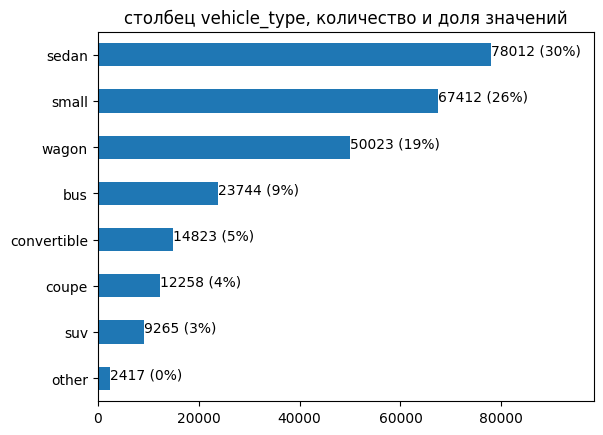

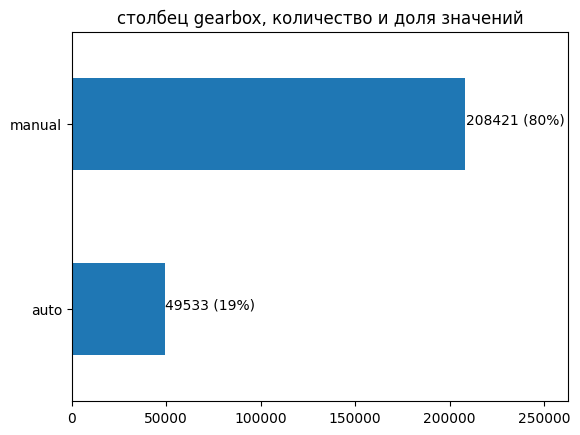

Index(['golf', 'other', '3er', 'polo', 'corsa', 'astra', 'passat', 'a4',
       'c_klasse', '5er'],
      dtype='object')

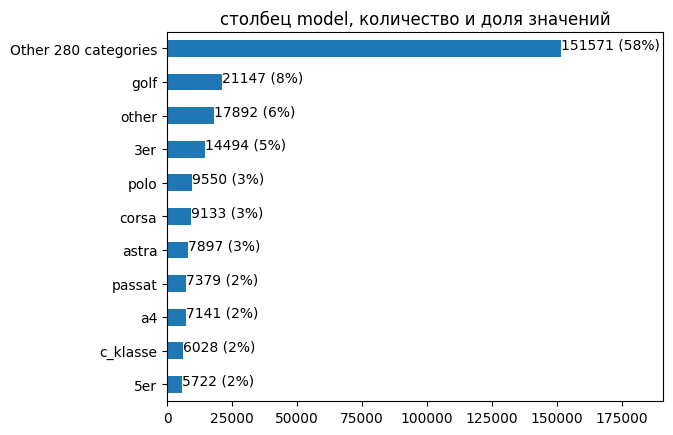

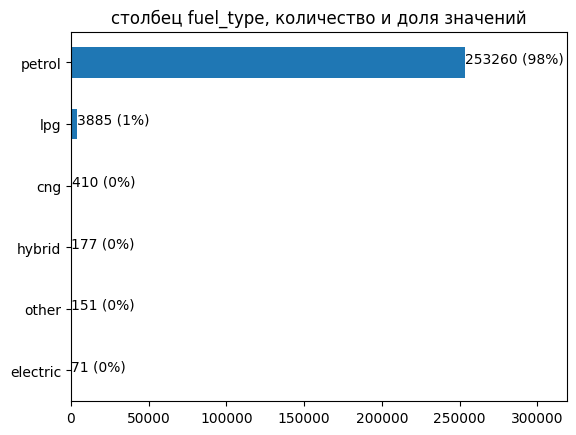

Index(['volkswagen', 'opel', 'bmw', 'mercedes_benz', 'audi', 'ford', 'renault',
       'peugeot', 'fiat', 'seat'],
      dtype='object')

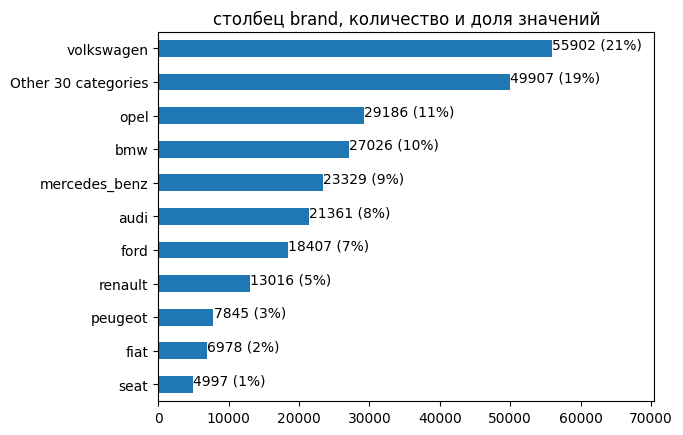

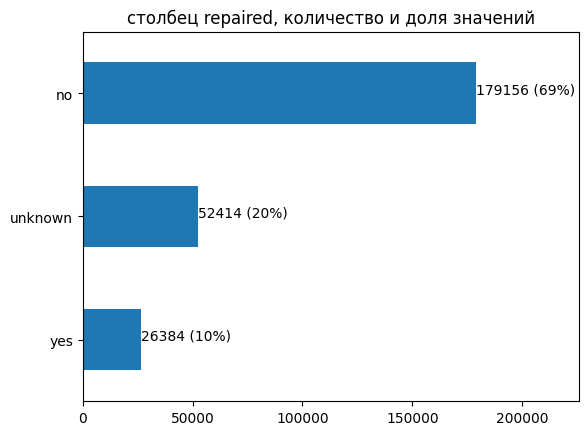

Int64Index([65428, 10115, 66333, 44145, 13357, 32257, 52525, 26789, 78224,
            48249],
           dtype='int64')

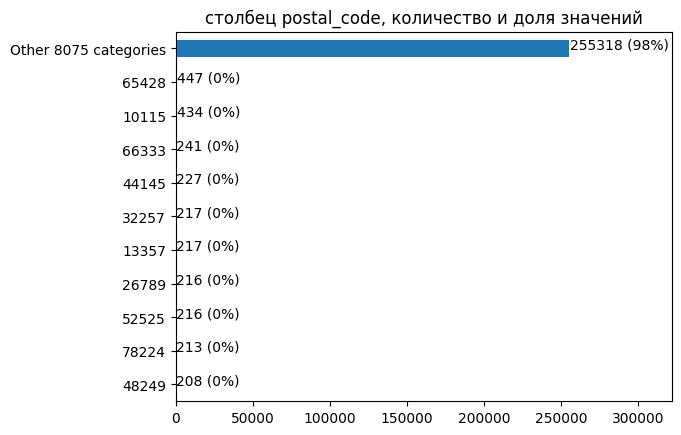

'********** Следующий признак: registration_year'

"фильтр = ''"

count    257954.000000
mean       2004.325760
std          95.378825
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: registration_year, dtype: float64

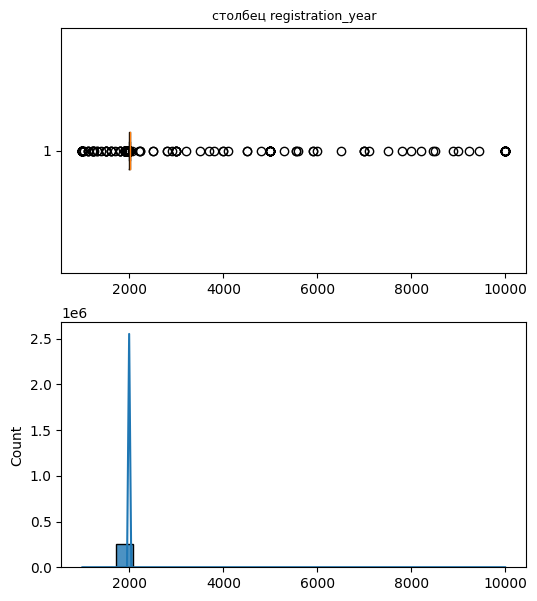

'********** Следующий признак: power'

"фильтр = ''"

count    257954.000000
mean        110.091051
std         196.887559
min           0.000000
25%          68.000000
50%         105.000000
75%         141.000000
max       20000.000000
Name: power, dtype: float64

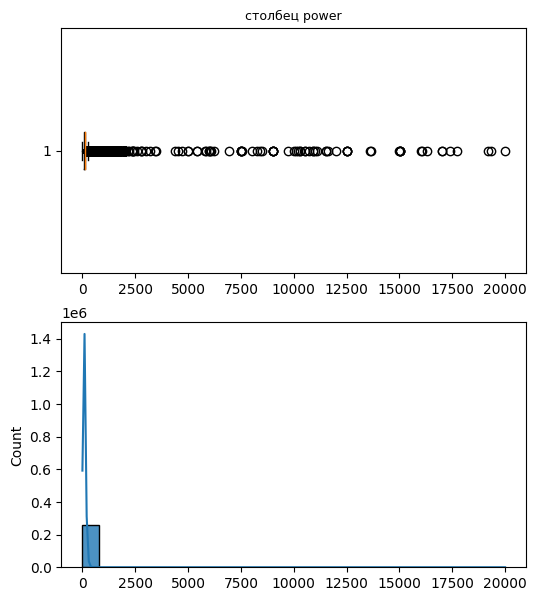

'********** Следующий признак: kilometer'

"фильтр = ''"

count    257954.000000
mean     128185.858719
std       37933.517481
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

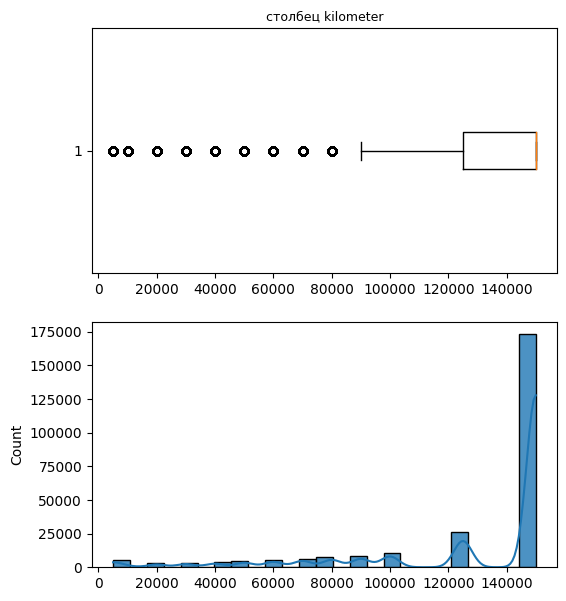

'********** Следующий признак: registration_month'

"фильтр = ''"

count    257954.000000
mean          5.707266
std           3.730992
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          12.000000
Name: registration_month, dtype: float64

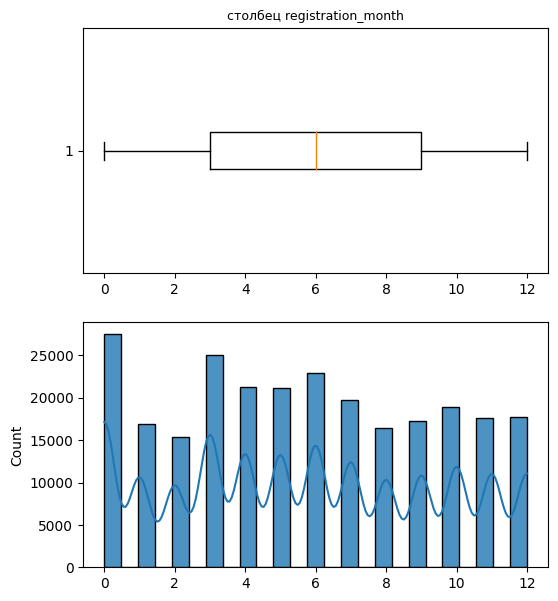

'********** Следующий признак: number_of_pictures'

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    257954.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: number_of_pictures, dtype: float64

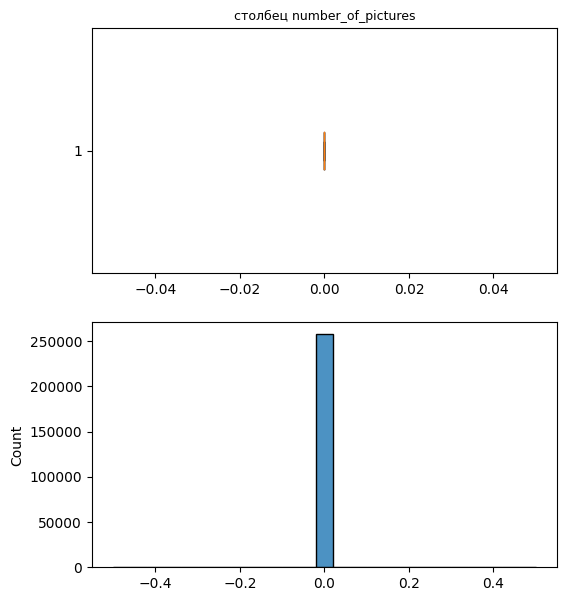

'********** Следующий признак: created_year'

"фильтр = ''"

count    257954.000000
mean       2015.999926
std           0.009022
min        2014.000000
25%        2016.000000
50%        2016.000000
75%        2016.000000
max        2016.000000
Name: created_year, dtype: float64

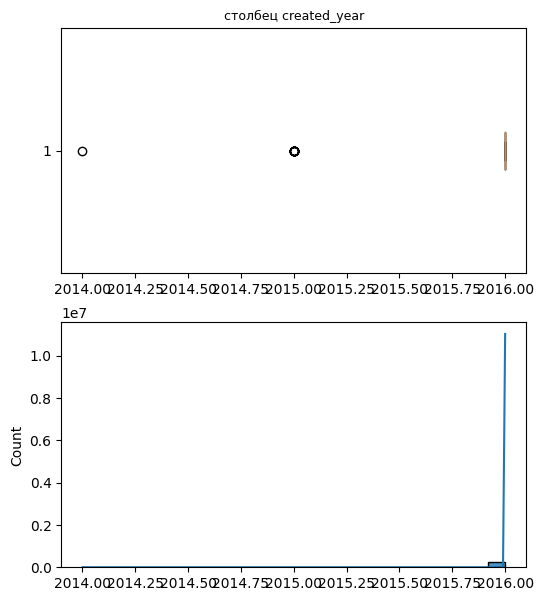

'********** Следующий признак: created_month'

"фильтр = ''"

count    257954.000000
mean          3.160862
std           0.376369
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max          12.000000
Name: created_month, dtype: float64

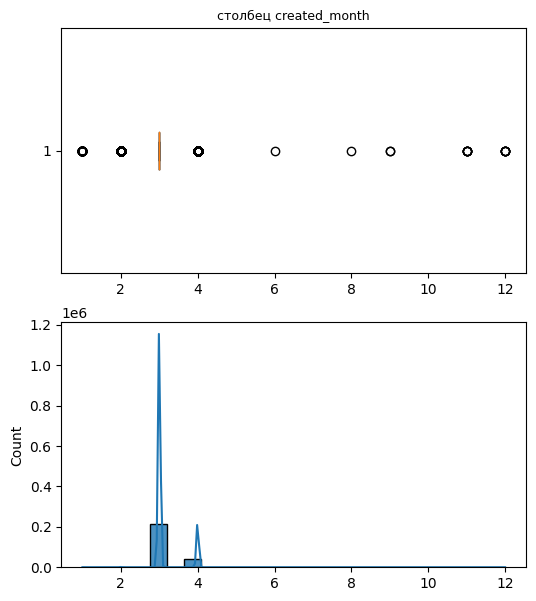

In [22]:
do_eda(X_train)

'********** Следующий признак: price'

"фильтр = ''"

count    257954.000000
mean       4401.059243
std        4507.886062
min           0.000000
25%        1001.000000
50%        2700.000000
75%        6350.000000
max       20000.000000
Name: price, dtype: float64

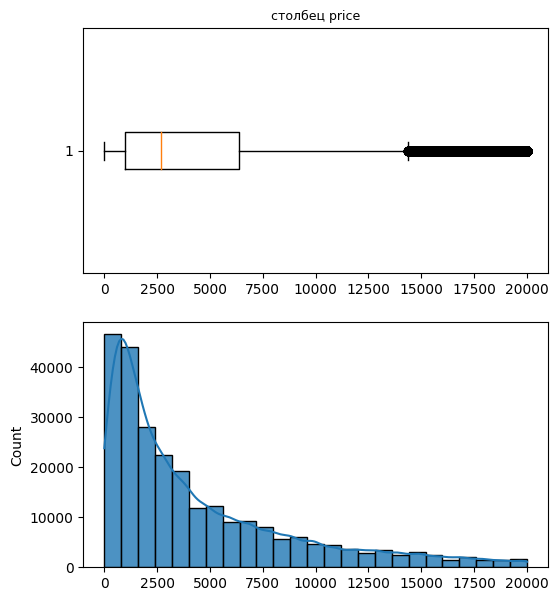

In [23]:
do_eda(pd.DataFrame({"price": y_train}))

## Выводы по EDA
1. TOP3 типов авто: sedan, small, wagon
1. TOP5 брендов: volkswagen, opel, bmw, mercedes, audi
1. 80% машин с автоматической коробкой
1. 98% машин на бензине
    1. 👷✅ удалим этот признак как малоинформативную.
1. postal_code имеет слишком много различных значений, являясь при этом категориальным. Это потребует большой энкодер, при этом распределение слишком равномерно, судя по пирогу
    1. 👷✅ попробуем укрупнить эту категорию по первой части индекса
1. Есть странные года регистрации автомобиля (например, 1000 или 8000)
    1. 👷✅ удалим такие автомобили
1. Года регистрации объявления - 2015 и 2016 
    1. 👷✅  удалим автомобили младше 2016
    1. 👷✅ сама год и месяц регистрации больше не нужны - удалим их тоже
1. Медианная мощность (л.с.) 105. Удалим машины со странной мощностью (<10 лс и >1600, машины же с 10 и 1500+ л. с. продаются на auto.ru - оставим всё, что укладывается в этот порог)
1. Медианный пробег (150 тыс. км) равен максимальному пробегу.
    1. это очень странно, но ничего менять не будем - машины могут быть и новые без пробега, так и совсем старые. Возможно, система не даёт ввести пробег больше?
    1. 👷✅ Нужно написать в отчёте продакт-менеджеру - пусть проверят, правильно ли это. Ведь пробег - по сути своей довольно важный признак.
1. Распределение по месяцам - относительно равномерное
    1. 👷✅ можно удалить, как малоинфомативный признак.
1. number_of_pictures всегда = 0
    1. 👷✅ нужно удалить, как неинфомативный признак.

Выясним точнее год и месяц создания объявления (учтём это затем при удалении объявлений с невалидной датой регистрации авто):

In [24]:
max(X_train['date_created'])

Timestamp('2016-04-07 00:00:00')

In [25]:
X_train = X_train.query('registration_year >= 1980 and '
        '(registration_year <= 2015 or (registration_year == 2016 and registration_month < 4))')

In [26]:
X_train = X_train.drop(['date_created', 'created_year', 'created_month'], axis=1)
X_test = X_test.drop(['date_created', 'created_year', 'created_month'], axis=1)

In [27]:
#v2
#X_train = X_train.query('power >= 10 and power <= 1600')

X_train.loc[(X_train['power'] <10) | (X_train['power'] > 1600), 'power'] = \
    X_train.groupby(['brand', 'model'])['power'] \
        .transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#v2 👷🚨[SOS] не удалось заменить mode на median - как это можно сделать?

In [28]:
columns_to_delete = ['fuel_type', 'registration_month','number_of_pictures']
X_train = X_train.drop(columns_to_delete, axis=1)
X_test = X_test.drop(columns_to_delete, axis=1)

In [29]:
X_train['postal_code']

308359    37176
88776     24855
179603    58675
185408    45130
33339     70794
          ...  
111330    63820
121157    34346
265141    94439
133461    34225
123281    54675
Name: postal_code, Length: 240681, dtype: object

ChatGPT уверяет, что все эти индексы принадлежат Германии:
```
Все перечисленные вами почтовые индексы принадлежат Германии. Вот подробная информация по каждому из них:​
🇩🇪 Германия
37176 — Гессен, район Гёппинген
58675 — Северный Рейн-Вестфалия, район Хемер
45130 — Северный Рейн-Вестфалия, город Эссен
70794 — Баден-Вюртемберг, город Фильдерштадт
36039 — Алабама, США
63820 — Бавария, город Эльзенфельд
34346 — Гессен, район Гёппинген
94439 — Бавария, район Реген
34225 — Гессен, район Гёппинген
54675 — Рейнланд-Пфальц, район Эйфелькрейс Битбург-Прюм
```

Ответ ChatGPT про количество первых цифр для крупных регионов:

```
Формат немецкого почтового индекса:
Всегда состоит из 5 цифр
Первая цифра определяет большой регион или федеральную землю (или их часть)
Вторая цифра помогает уточнить регион внутри этой области
0	Восточная Германия (Берлин, Бранденбург, Тюрингия)
1	Берлин и восток Бранденбурга
2	Шлезвиг-Гольштейн, Гамбург, Мекленбург-Передняя Померания
3	Нижняя Саксония, часть Саксонии
4	Рурская область (Северный Рейн-Вестфалия)
5	Центральная часть Сев. Рейна-Вестфалии, Рейнланд-Пфальц
6	Гессен, Рейнланд-Пфальц, Саар
7	Баден-Вюртемберг
8	Бавария (север и запад)
9	Бавария (восток и юг), часть Тюрингии и Саксонии
```

Проведём [фактчекниг](https://ru.ruwiki.ru/wiki/%D0%9F%D0%BE%D1%87%D1%82%D0%BE%D0%B2%D1%8B%D0%B5_%D0%B8%D0%BD%D0%B4%D0%B5%D0%BA%D1%81%D1%8B_%D0%B2_%D0%93%D0%B5%D1%80%D0%BC%D0%B0%D0%BD%D0%B8%D0%B8) и оставим первую цифру почтового кода в качестве фичи:

In [30]:
X_train['postal_code'] = X_train['postal_code'].apply(lambda x: "0" if len(str(x)) < 5 else str(x)[:1])
X_train['postal_code']

308359    3
88776     2
179603    5
185408    4
33339     7
         ..
111330    6
121157    3
265141    9
133461    3
123281    5
Name: postal_code, Length: 240681, dtype: object

Удалим цены ниже 100:

In [31]:
mask = y_train >= 100
X_train = X_train[mask]
y_train = y_train[mask]

C:\Users\Papa\AppData\Local\Temp\ipykernel_19508\980376495.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X_train[mask]


## Оценим графики после удалений:

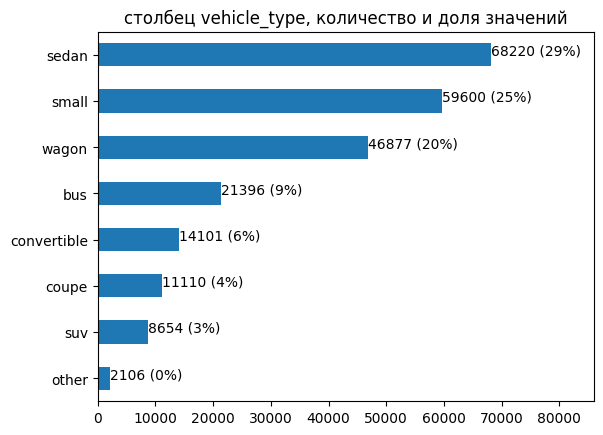

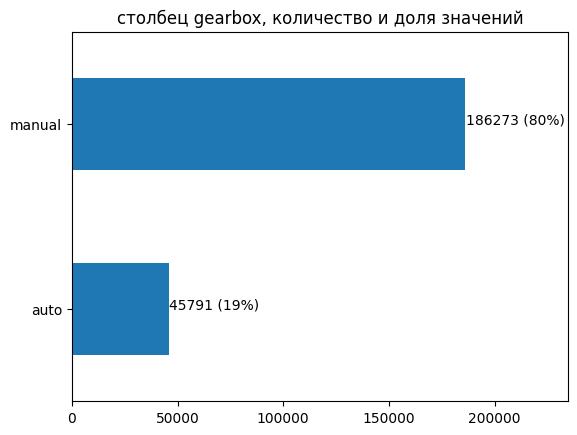

Index(['golf', 'other', '3er', 'polo', 'corsa', 'astra', 'passat', 'a4',
       'c_klasse', '5er'],
      dtype='object')

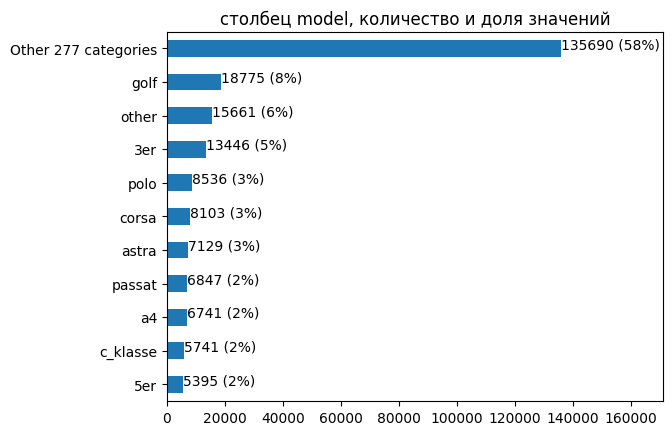

Index(['volkswagen', 'opel', 'bmw', 'mercedes_benz', 'audi', 'ford', 'renault',
       'peugeot', 'fiat', 'seat'],
      dtype='object')

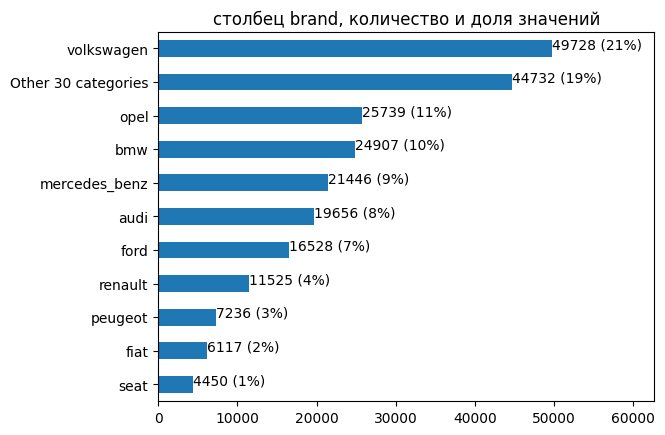

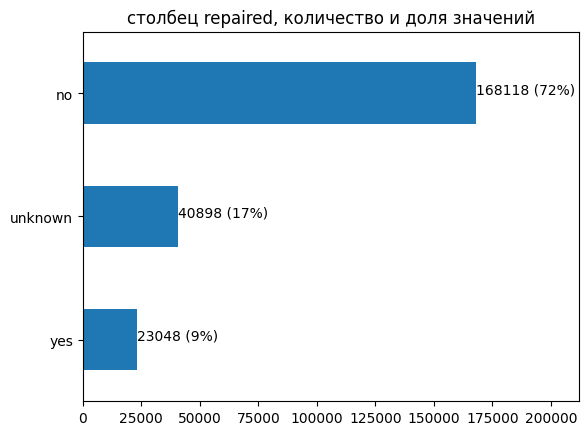

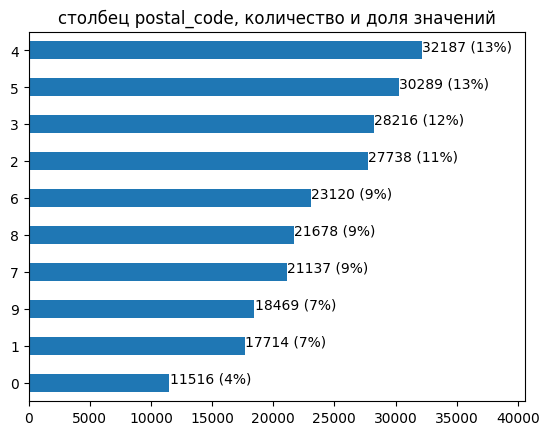

'********** Следующий признак: registration_year'

"фильтр = ''"

count    232064.000000
mean       2002.705525
std           5.839323
min        1980.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2016.000000
Name: registration_year, dtype: float64

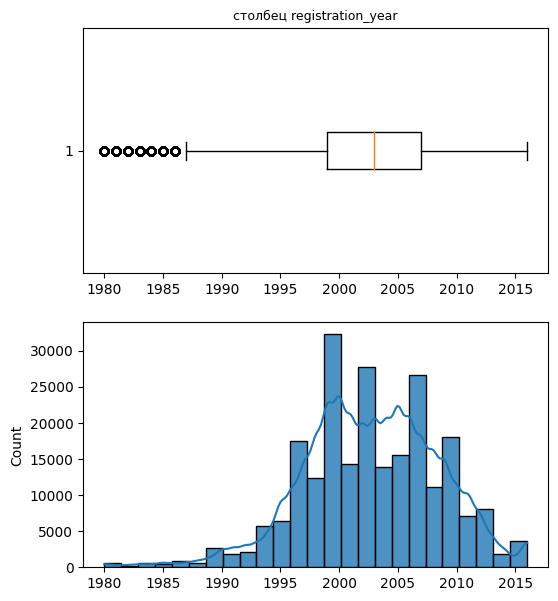

'********** Следующий признак: power'

"фильтр = ''"

count    232064.000000
mean        117.811461
std          60.455641
min           0.000000
25%          75.000000
50%         109.000000
75%         147.000000
max        1600.000000
Name: power, dtype: float64

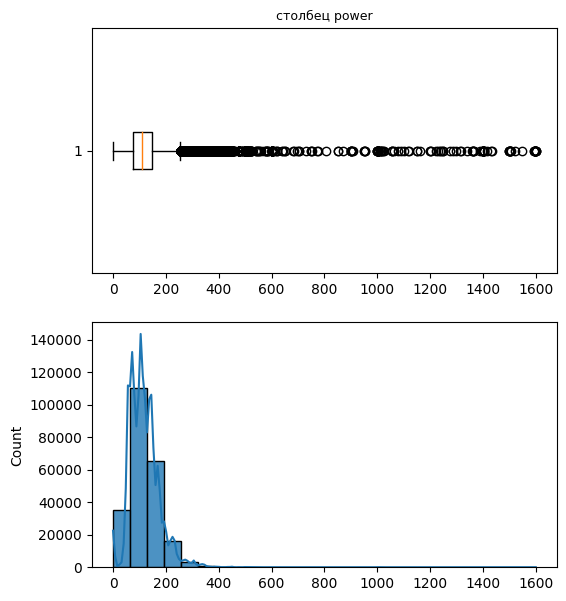

'********** Следующий признак: kilometer'

"фильтр = ''"

count    232064.000000
mean     128623.353902
std       36957.650111
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

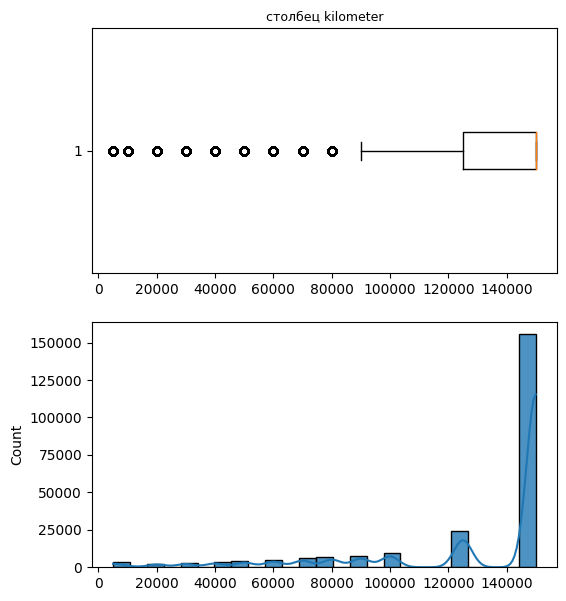

In [32]:
do_eda(X_train)

## Удалим из y_train те же строки, что удалили в процессе из X_train и сбросим индексы

In [33]:
y_train = y_train[X_train.index]
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Проверим мультиколлинеарность

In [34]:
X_train

,vehicle_type,registration_year,gearbox,power,model,kilometer,brand,repaired,postal_code
0,wagon,2001,manual,163,c_klasse,150000,mercedes_benz,no,3
1,sedan,1995,auto,0,other,125000,ford,yes,2
2,wagon,1998,manual,61,transporter,150000,volkswagen,no,5
3,coupe,2006,manual,300,other,50000,nissan,no,4
4,suv,2000,manual,88,jimny,150000,suzuki,yes,7
...,...,...,...,...,...,...,...,...,...
232059,wagon,2008,auto,232,a6,90000,audi,no,6
232060,sedan,1996,manual,75,golf,150000,volkswagen,unknown,3
232061,sedan,1990,auto,165,100,150000,audi,no,9
232062,small,2002,manual,68,fiesta,150000,ford,no,3


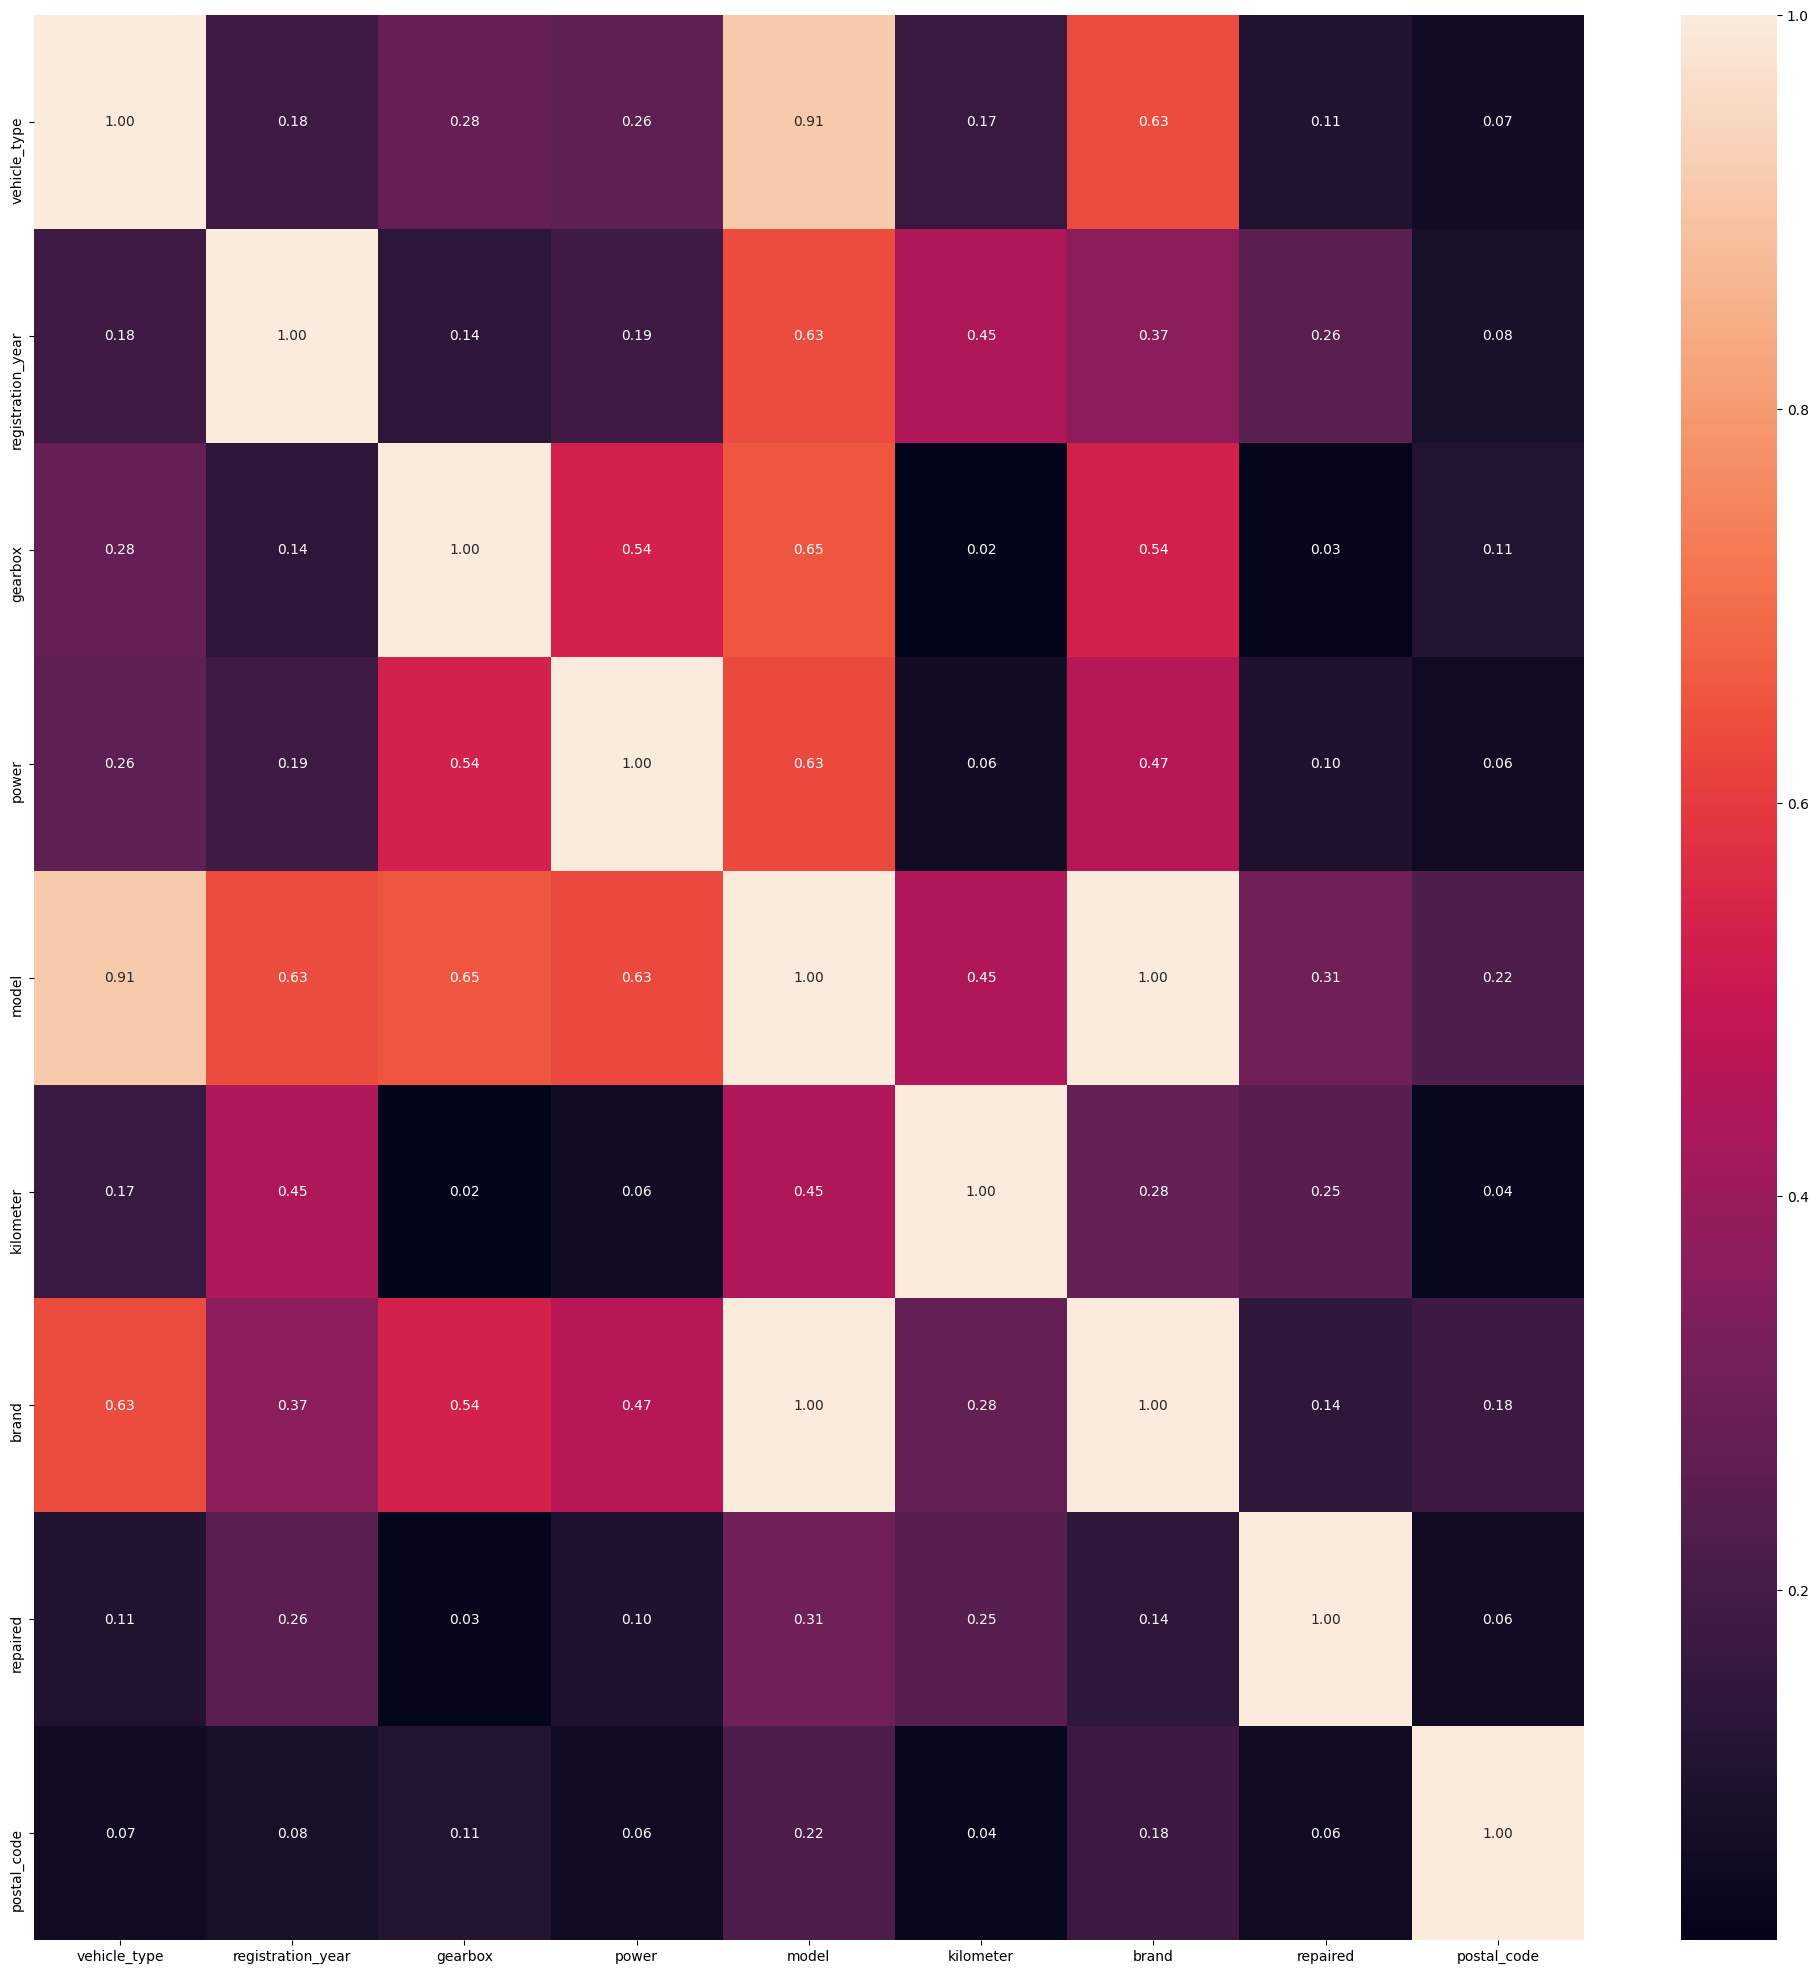

In [35]:
_, ax = plt.subplots(figsize=(25,25))
ph_mx = X_train.phik_matrix(interval_cols=['kilometer', 'power', 'registration_year'],
                bins={'kilometer':10, 'power':10, 'registration_year':10})
sns.heatmap(ph_mx, annot=True, fmt='.2f', ax=ax);

*Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

In [36]:
n = len(ph_mx.columns)
for i in range(1,n):
    for j in range(0,i):
        if ph_mx.iloc[i][j] >= 0.9:
            display (f'{ph_mx.columns[i]} <-> {ph_mx.columns[j]}')           

'model <-> vehicle_type'

'brand <-> model'

In [37]:
X_train = X_train.drop(['brand'], axis=1)
X_test = X_test.drop(['brand'], axis=1)

In [38]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232064 entries, 0 to 232063
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   vehicle_type       232064 non-null  object
 1   registration_year  232064 non-null  int64 
 2   gearbox            232064 non-null  object
 3   power              232064 non-null  int64 
 4   model              232064 non-null  object
 5   kilometer          232064 non-null  int64 
 6   repaired           232064 non-null  object
 7   postal_code        232064 non-null  object
dtypes: int64(3), object(5)
memory usage: 14.2+ MB


In [39]:
X_train.head()

,vehicle_type,registration_year,gearbox,power,model,kilometer,repaired,postal_code
0,wagon,2001,manual,163,c_klasse,150000,no,3
1,sedan,1995,auto,0,other,125000,yes,2
2,wagon,1998,manual,61,transporter,150000,no,5
3,coupe,2006,manual,300,other,50000,no,4
4,suv,2000,manual,88,jimny,150000,yes,7


# Проверим сбалансированность тренировочной выборки относительно целевого класса (в случае классификации)

В нашем случае - задача регрессии.

(по итогам этого проекта делаю себе шаблон, добавлять лишнее не буду в будущем)

# Обучение моделей

## Pipeline

In [40]:
cat_columns = ['vehicle_type', 'gearbox', 'model', 'repaired', 'postal_code']
for c in X_train.columns:
    if X_train[c].dtype == 'O':
        X_train[c] = X_train[c].astype("category")
display(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232064 entries, 0 to 232063
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   vehicle_type       232064 non-null  category
 1   registration_year  232064 non-null  int64   
 2   gearbox            232064 non-null  category
 3   power              232064 non-null  int64   
 4   model              232064 non-null  category
 5   kilometer          232064 non-null  int64   
 6   repaired           232064 non-null  category
 7   postal_code        232064 non-null  category
dtypes: category(5), int64(3)
memory usage: 6.7 MB


None

In [41]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232064 entries, 0 to 232063
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   vehicle_type       232064 non-null  category
 1   registration_year  232064 non-null  int64   
 2   gearbox            232064 non-null  category
 3   power              232064 non-null  int64   
 4   model              232064 non-null  category
 5   kilometer          232064 non-null  int64   
 6   repaired           232064 non-null  category
 7   postal_code        232064 non-null  category
dtypes: category(5), int64(3)
memory usage: 6.7 MB


In [42]:
num_columns = ['registration_year', 'power', 'kilometer']

cat_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     #v1 не работает, всё ломается если 'ohe'-строчку заменить на следующую строчку:
     # ('Target encoding', TargetEncoder())
     #v1 ошибка при обучении: AttributeError: 'super' object has no attribute '__sklearn_tags__' - что с ней делать, не понятно
     # Помогите, пожалуйста, разобраться.
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

data_preprocessor = ColumnTransformer(
    [
        ('ohe', cat_pipe, cat_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
) 


In [43]:
def train_test_model(params, X_train, y_train, X_test, y_test):
    
    results = {
    "model_name": [],
    "crossval_train_time": [],
    "crossval_test_time": [],
    "crossval_best_score_rmse": [],
    }
    models = []
    
    for p in params:
        # train
        randomized_search = RandomizedSearchCV(
            p[0], 
            p[1],
            cv=2,
            scoring="neg_root_mean_squared_error",
            random_state=RANDOM_STATE,
            n_iter=3,
            verbose = 3,
            n_jobs=-1
        )
        results ["model_name"] += [p[0]['models']]

        randomized_search.fit(X_train, y_train)
        results ["crossval_train_time"] += \
            [randomized_search.cv_results_['mean_fit_time']\
            [randomized_search.best_index_]]
        results ["crossval_test_time"] += \
            [randomized_search.cv_results_['mean_score_time']\
            [randomized_search.best_index_]]
        results ["crossval_best_score_rmse"] += [randomized_search.best_score_]
        
        models.append (randomized_search.best_estimator_)

    return results, models

In [44]:
params = [
    (
        Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', LinearRegression())
        ]),
        {
            'preprocessor__num': ['passthrough']
        }
    )
   ,
    (
        Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', lgb.LGBMRegressor())
        ]),
        {
            'models__learning_rate': [0.05],
            ##'models__num_leaves': [90,200],
            'models__boosting_type' : ['gbdt'],
            ##'models__max_depth' : [5,8],
            ##'models__colsample_bytree' : [0.5,0.7],
            ##'models__subsample' : [0.5,0.7],
            ##'models__min_split_gain' : [0.01],
            ##'models__min_data_in_leaf':[10]
        }
    )
    ,
## SVR учится очень долго на большом датасете, пришлось выключить
##    (
##        Pipeline([
##            ('preprocessor', data_preprocessor),
##            ('models', SVR())
##        ]),
##        {
##            'models__kernel': ['rbf'],
##            'models__degree': range(2, 7),
##            #'models__epsilon': [0.1, 0.5],
##            'models__C': range(1, 5),
##            'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
##        }
##    )
##    ,
    (
        Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', RandomForestRegressor(random_state=RANDOM_STATE))
        ]),
        {
            'models__max_depth': range(30, 200),
            ##'models__n_estimators': range(30, 200),
            ##'models__min_samples_split': range(2, 50),
            ##'models__min_samples_leaf': range(1, 10),
            ##'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
        }
    )
]

In [45]:
%%time
results, models = train_test_model (params, X_train, y_train, X_test, y_test)

Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=3. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=3. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 2 folds for each of 1 candidates, totalling 2 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 232064, number of used features: 285
[LightGBM] [Info] Start training from score 4631.052572
Fitting 2 folds for each of 3 candidates, totalling 6 fits
CPU times: total: 19min 18s
Wall time: 31min 4s


# Анализ результатов

## Метрики качества на валидационной выборке

In [46]:
results_df = pd.DataFrame(results)
display (results_df)

,model_name,crossval_train_time,crossval_test_time,crossval_best_score_rmse
0,LinearRegression(),5.330842,0.538428,-2584.961571
1,LGBMRegressor(),1.671950,0.917176,-1792.645251
2,RandomForestRegressor(random_state=42),686.707411,11.085578,-1673.576903


## Метрики качества на тестовой выборке

Лучшая модель - LGBM (время обучения randomforest в ~400 раз больше) - оценим тестовую выборку на LGBM.

In [47]:
lgbm = models[1]

In [51]:
y_pred = lgbm.predict(X_test)
display ('RMSE на тестовой выборке = ', root_mean_squared_error(y_test, y_pred))

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


'RMSE на тестовой выборке = '

2037.9996613893459

# Отчёт и выводы

- В соответствии с поставленной задачей(см. первый раздел)
    - была проведена подготовка данных и их разведочный анализ, в результате которых:
        - были исправлены имена полей, исправлены типы данных, удалены малополезные признаки (в т. ч. с учётом мультиколлинеарности), заполнены пропуски, удалены явные и неявные дубликаты, 
    - была натренирована модель, предсказывающая цену автомобиля
        - выбрана наиболее оптимальная модель - **LGBMRegressor**, показавшая наилучшие результаты:
            - качество предсказания (**KPI < 2500**) = 2038
            - время обучения модели = 1.6 сек.
            - время предсказания модели на тестовой выборке = 0.9 сек.
    - для продакт-менеджера есть предложение по итогам разведовательного анализа:
        - Медианный пробег (150 тыс. км) равен максимальному пробегу. Это очень странно. Возможно, система не даёт ввести пробег больше?
        - есть и другие странности в данных - есть смысл на них посмотреть дата-инженеру (раздел "Выводы по EDA")

# Appendix - comments legend

These icons and [tags] were used to simplify visualization and searching for conclusions, open questions and subtasks, not to forget to finish/check something important. It's convenient to copy a cell from here and paste it into the right place, adding details and then find it by tags or visually.

👷🚩[todo] 

⬆ this task is to be done

👷✅ 

⬆ the task has been done

👷🚨[SOS] 

⬆ need help

👷🔔[reminder] 

⬆ some work to do or check later

⚠️[!] 

⬆ important constraints or facts

💡 [!] 

⬆ something interesting

🏭 [data transformation] this change ⤴ should be done before training/testing/inference

👷🚧🚧🚧🚧🚧 [in progress] 

⬆ in progress right now

🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧⬇️🚧

➡️ some code to be reworked ⬅️

🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧⬆️🚧